# Roman Urdu Sentiment Analysis using XLM-RoBERTa + HAF-BiGRU

[![Python](https://img.shields.io/badge/Python-3.10-blue)](https://python.org)
[![PyTorch](https://img.shields.io/badge/PyTorch-2.x-orange)](https://pytorch.org)
[![HuggingFace](https://img.shields.io/badge/🤗-Transformers-yellow)](https://huggingface.co)
[![GPU](https://img.shields.io/badge/GPU-Tesla_T4-green)](https://kaggle.com)
[![License](https://img.shields.io/badge/License-MIT-lightgrey)](LICENSE)

---

## Overview

This notebook presents a novel **HAF-BiGRU** (Hierarchical Attention Fusion with BiGRU) classification head for Roman Urdu sentiment analysis, mounted on a pretrained **XLM-RoBERTa** encoder.

**Dataset:** [RUWV-NSR](https://doi.org/10.17632/v5jfhsvtmd.5) — Ahmed, M. (2024). Mendeley Data, V5.  
**Task:** 3-class sentiment classification (Negative / Neutral / Positive)  
**Platform:** Kaggle Notebook · Tesla T4 GPU (15.6 GB VRAM)

---

## Novel Contribution: HAF-BiGRU Head

| Component | Standard Approach | This Work |
|---|---|---|
| Classification input | Single `[CLS]` from final layer | `[CLS]` from last **k=4** layers |
| Layer fusion | None | Learned softmax attention (HAF) |
| Sequence model | Flat linear | Bidirectional GRU |
| Classifier | Single linear | 3-layer MLP with GELU |

The HAF (Hierarchical Attention Fusion) module learns which encoder layers contribute most to sentiment classification, instead of discarding all but the final layer.

---

## Key Design Decisions

| Choice | Value | Justification |
|---|---|---|
| Encoder | `cardiffnlp/twitter-xlm-roberta-base-sentiment` | Pretrained on multilingual social media text |
| `MAX_LEN` | 96 | Covers p95 of dataset (39 words ≈ 58 subword tokens) |
| Loss | Focal Loss (γ=2) + Label Smoothing (ε=0.05) | Handles class imbalance; prevents overconfidence |
| Augmentation | EDA on Neutral class only (×1) | Addresses 1.75× imbalance without data leakage |
| Stage-1 LR | 1×10⁻³ | Standard for head-only linear probe |
| Stage-2 LR | 2×10⁻⁵ | Standard transformer fine-tune (Devlin et al., 2019) |
| Precision | `fp16` | Tesla T4 Tensor Cores (T4 has no bfloat16 support) |

---

## Results

| Metric | Score |
|---|---|
| **Accuracy** | **73.09%** |
| **Macro F1** | **70.21%** |
| Weighted F1 | 72.48% |
| Macro Precision | 71.56% |
| Macro Recall | 69.83% |

---

## Repository Structure

```
├── sentiment.ipynb          ← This notebook
├── README.md
└── requirements.txt
```

---

## References

1. Ahmed, M. (2024). RUWV-NSR (v5). *Mendeley Data*. https://doi.org/10.17632/v5jfhsvtmd.5  
2. Conneau et al. (2020). Unsupervised Cross-lingual Representation Learning at Scale. *ACL 2020*.  
3. Lin et al. (2017). Focal Loss for Dense Object Detection. *ICCV 2017*.  
4. Wei & Zou (2019). EDA: Easy Data Augmentation. *EMNLP 2019*.  
5. Devlin et al. (2019). BERT: Pre-training of Deep Bidirectional Transformers. *NAACL 2019*.


## 1. Environment Setup

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/iitmkaggle/roman-urdu/Roman Urdu reviews Dataset with English translation.csv


In [ ]:
!pip install -q transformers>=4.40.0 datasets scikit-learn sentencepiece protobuf seaborn

In [ ]:
import pandas as pd
import numpy as np
import re
import random
import torch
from torch import nn
import torch.nn.functional as F
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score,
                              recall_score, confusion_matrix, classification_report)
from sklearn.utils.class_weight import compute_class_weight

from transformers import (
    AutoTokenizer, AutoModel,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
from transformers.modeling_outputs import SequenceClassifierOutput
from datasets import Dataset as HFDataset, Value

import matplotlib.pyplot as plt
import seaborn as sns

# ── Device ─────────────────────────────────────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')

# ── Reproducibility ─────────────────────────────────────────────────────
SEED = 42
def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(SEED)

# ── Hyperparameters ─────────────────────────────────────────────────────
MODEL_NAME   = 'cardiffnlp/twitter-xlm-roberta-base-sentiment'
MAX_LEN      = 96       # covers p95 of dataset (39 words ≈ 58 subword tokens)
HAF_K        = 4        # number of encoder layers fused by HAF
BIGRU_HIDDEN = 256
MLP_HIDDEN   = 512
DROPOUT      = 0.1
GAMMA        = 2.0      # Focal Loss gamma — Lin et al. (2017)
LABEL_SMOOTH = 0.05     # label smoothing — prevents overconfident predictions
LABEL_NAMES  = ['Negative', 'Neutral', 'Positive']

# ── T4-optimised training settings ──────────────────────────────────────
# NOTE: fp16=True (not bf16) — Tesla T4 has fp16 Tensor Cores only
T4 = dict(
    fp16                   = True,
    optim                  = 'adamw_torch_fused',
    dataloader_num_workers = 2,
    dataloader_pin_memory  = True,
)
print('\nConfig loaded.')

GPU  : Tesla T4
VRAM : 15.6 GB

Config loaded.


## 2. Data Loading & Preprocessing

In [ ]:
df = pd.read_csv(
    '/kaggle/input/datasets/iitmkaggle/roman-urdu/Roman Urdu reviews Dataset with English translation.csv',
    encoding='latin-1'
)
df = df.rename(columns={'ROMAN URDU REVIEWS': 'text', 'SENTIMENT': 'label'})
df = df[['text', 'label']].copy()

# ── Label mapping ────────────────────────────────────────────────────
def map_sentiment(x):
    x = str(x).lower().strip()
    if x in ['positive', 'very positive', 'verypositive']:            return 2
    if x in ['negative', 'very negative', 'verynegative', 'neative']: return 0
    return 1

df['labels'] = df['label'].apply(map_sentiment)
df = df.drop(columns=['label'])

# ── Text cleaning ────────────────────────────────────────────────────
def clean_text(t):
    t = str(t).lower()
    t = re.sub(r'http\S+|www\S+', '', t)      # remove URLs
    t = re.sub(r'[^a-z0-9\s]', '', t)         # remove special characters
    t = re.sub(r'(.)\1{2,}', r'\1\1', t)      # collapse elongation: sooo→soo
    return t.strip()

df['text'] = df['text'].apply(clean_text)

vc = df['labels'].value_counts().sort_index()
print(f'Total samples : {len(df):,}')
print(f'Negative      : {vc[0]:,}  ({vc[0]/len(df)*100:.1f}%)')
print(f'Neutral       : {vc[1]:,}  ({vc[1]/len(df)*100:.1f}%)')
print(f'Positive      : {vc[2]:,}  ({vc[2]/len(df)*100:.1f}%)')

Total samples : 28,090
Negative      : 10,349  (36.8%)
Neutral       : 6,445  (22.9%)
Positive      : 11,296  (40.2%)


## 3. Train / Validation / Test Split

In [ ]:
# Stratified 80/10/10 split
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['labels'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['labels'], random_state=SEED
)
for d in [train_df, val_df, test_df]:
    d.reset_index(drop=True, inplace=True)

print('=' * 65)
print('  Table 1: Dataset Statistics — RUWV-NSR (Ahmed 2024)')
print('=' * 65)
print(f"  {'Split':<8} {'Negative':>10} {'Neutral':>10} {'Positive':>10} {'Total':>8}")
print('  ' + '-' * 52)
for nm, d in [('Train', train_df), ('Val', val_df), ('Test', test_df), ('Total', df)]:
    vc = d['labels'].value_counts().sort_index()
    print(f"  {nm:<8} {vc.get(0,0):>10,} {vc.get(1,0):>10,} {vc.get(2,0):>10,} {len(d):>8,}")
print('=' * 65)

  Table 1: Dataset Statistics — RUWV-NSR (Ahmed 2024)
  Split      Negative    Neutral   Positive    Total
  ----------------------------------------------------
  Train         8,279      5,156      9,037   22,472
  Val           1,035        644      1,130    2,809
  Test          1,035        645      1,129    2,809
  Total        10,349      6,445     11,296   28,090


## 4. EDA Augmentation (Neutral Class Only)

We apply **EDA** (Wei & Zou, EMNLP 2019) to the Neutral class only, which is the minority class (22.9% vs 36.8% Negative / 40.2% Positive). Three operations are applied per sample: random word deletion (p=0.1), random word swap, and random word insertion from a Neutral-class vocabulary pool.

**Why EDA instead of RandomOverSampler?**  
`RandomOverSampler` creates exact duplicate rows, which the model memorises rather than generalising from. EDA generates syntactically varied augmentations of each sentence.


In [ ]:
def rwd(words, p=0.1):
    """Random word deletion."""
    if len(words) == 1: return words[:]
    out = [w for w in words if random.random() > p]
    return out if out else [random.choice(words)]

def rws(words):
    """Random word swap."""
    out = words[:]
    if len(out) < 2: return out
    i, j = random.sample(range(len(out)), 2)
    out[i], out[j] = out[j], out[i]
    return out

def rwi(words, pool):
    """Random word insertion from vocab pool."""
    out = words[:]
    out.insert(random.randint(0, len(out)), random.choice(pool))
    return out

def eda(text, pool, seed=None):
    if seed is not None: random.seed(seed)
    words = text.split()
    if len(words) < 2: return text
    words = rwd(words)
    words = rws(words)
    words = rwi(words, pool)
    return ' '.join(words)

# Build vocabulary pool from Neutral class
all_words = []
for t in train_df[train_df['labels'] == 1]['text']:
    all_words.extend(t.split())
vocab_neu = [w for w, c in Counter(all_words).items() if c >= 3]
print(f'Neutral vocabulary pool: {len(vocab_neu):,} unique words (freq ≥ 3)')

# Augment once (×1) — keeps imbalance ratio reasonable
random.seed(SEED)
aug_rows = []
neu_sub  = train_df[train_df['labels'] == 1]
for idx, row in neu_sub.iterrows():
    aug = eda(row['text'], vocab_neu, seed=SEED + idx)
    if aug.strip() and aug != row['text']:
        aug_rows.append({'text': aug, 'labels': 1})

train_aug = pd.concat(
    [train_df, pd.DataFrame(aug_rows)], ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

vc_b = train_df['labels'].value_counts().sort_index()
vc_a = train_aug['labels'].value_counts().sort_index()
print(f'\nBefore EDA: Neg={vc_b[0]:,}  Neu={vc_b[1]:,}  Pos={vc_b[2]:,}  Total={len(train_df):,}')
print(f'After  EDA: Neg={vc_a[0]:,}  Neu={vc_a[1]:,}  Pos={vc_a[2]:,}  Total={len(train_aug):,}')
print(f'Imbalance ratio: {max(vc_a.values)/min(vc_a.values):.2f}x')

Neutral vocabulary pool: 3,024 unique words (freq ≥ 3)

Before EDA: Neg=8,279  Neu=5,156  Pos=9,037  Total=22,472
After  EDA: Neg=8,279  Neu=15,436  Pos=9,037  Total=32,752
Imbalance ratio: 1.86x


## 5. Tokenisation

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f'Tokenizer : {MODEL_NAME}')
print(f'Vocab size: {tokenizer.vocab_size:,}')
print(f'MAX_LEN   : {MAX_LEN}  (p95 of dataset = 39 words ≈ 58 subword tokens)')

def make_ds(df_):
    ds = HFDataset.from_pandas(df_[['text', 'labels']], preserve_index=False)
    ds = ds.cast_column('labels', Value('int64'))
    ds = ds.map(
        lambda b: tokenizer(b['text'], padding='max_length',
                            truncation=True, max_length=MAX_LEN),
        batched=True, remove_columns=['text']
    )
    ds.set_format('torch')
    return ds

train_ds = make_ds(train_aug)
val_ds   = make_ds(val_df)
test_ds  = make_ds(test_df)
print(f'\nTrain={len(train_ds):,}  Val={len(val_ds):,}  Test={len(test_ds):,}')
print(f'Feature keys: {list(train_ds[0].keys())}')

Tokenizer : cardiffnlp/twitter-xlm-roberta-base-sentiment
Vocab size: 250,002
MAX_LEN   : 96  (p95 of dataset = 39 words ≈ 58 subword tokens)

Train=32,752  Val=2,809  Test=2,809
Feature keys: ['input_ids', 'attention_mask', 'labels']


## 6. Model Architecture: XLM-RoBERTa + HAF-BiGRU

### HAF-BiGRU Head

The standard approach uses only the final-layer `[CLS]` token for classification. Our **HAF-BiGRU** head instead:

1. Extracts `[CLS]` from the **last k=4 encoder layers** → tensor of shape `(B, 4, 768)`
2. Applies **learned softmax attention** over the 4 layers (HAF module)
3. Passes the weighted sequence through a **Bidirectional GRU**
4. Feeds the GRU output through a **3-layer MLP** classifier

This allows the model to learn which encoder layers contain the most task-relevant representations for Roman Urdu sentiment.


In [ ]:
class HAFBiGRU(nn.Module):
    """Hierarchical Attention Fusion with Bidirectional GRU classification head."""

    def __init__(self, hidden_size, num_labels):
        super().__init__()
        self.k          = HAF_K
        # Learned attention weight per layer — initialised uniform
        self.layer_attn = nn.Parameter(torch.ones(HAF_K))
        self.bigru      = nn.GRU(hidden_size, BIGRU_HIDDEN,
                                  batch_first=True, bidirectional=True)
        self.mlp = nn.Sequential(
            nn.Linear(BIGRU_HIDDEN * 2, MLP_HIDDEN),
            nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(MLP_HIDDEN, MLP_HIDDEN // 2),
            nn.GELU(), nn.Dropout(DROPOUT),
            nn.Linear(MLP_HIDDEN // 2, num_labels),
        )

    def forward(self, hidden_states):
        # Stack [CLS] tokens from last k layers: (B, k, H)
        cls_stack = torch.stack(
            [h[:, 0, :] for h in hidden_states[-self.k:]], dim=1
        )
        # Apply softmax attention across layers
        attn_w   = F.softmax(self.layer_attn, dim=0)          # (k,)
        weighted = cls_stack * attn_w.unsqueeze(0).unsqueeze(-1)  # (B, k, H)
        # BiGRU over the 4 weighted layer representations
        _, h_n   = self.bigru(weighted)
        h_cat    = torch.cat([h_n[0], h_n[1]], dim=-1)         # (B, 2*BIGRU_HIDDEN)
        return self.mlp(h_cat)


class XLMRHAFBiGRU(nn.Module):
    """XLM-RoBERTa encoder with HAF-BiGRU classification head."""

    def __init__(self, model_name, num_labels=3):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(
            model_name, output_hidden_states=True
        )
        self.head = HAFBiGRU(self.encoder.config.hidden_size, num_labels)

    def forward(self, input_ids=None, attention_mask=None, labels=None, **kwargs):
        enc_out = self.encoder(input_ids=input_ids, attention_mask=attention_mask,
                               output_hidden_states=True)
        logits = self.head(enc_out.hidden_states)
        loss   = focal_loss(logits, labels.long()) if labels is not None else None
        return SequenceClassifierOutput(loss=loss, logits=logits)


# ── Focal Loss + Label Smoothing ────────────────────────────────────────
cw_arr = compute_class_weight('balanced', classes=np.array([0, 1, 2]),
                               y=train_aug['labels'].values)
cw = torch.tensor(cw_arr, dtype=torch.float32)

def focal_loss(logits, targets, gamma=GAMMA):
    # Cast weights to logits dtype (float16 when fp16=True)
    weights = cw.to(logits.device).to(logits.dtype)
    ce = F.cross_entropy(logits, targets, weight=weights,
                         reduction='none', label_smoothing=LABEL_SMOOTH)
    pt = torch.exp(-ce)
    return ((1 - pt) ** gamma * ce).mean()

class FocalTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get('labels').long()
        outputs = model(**inputs)
        loss    = focal_loss(outputs.logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_metrics(p):
    preds = p.predictions.argmax(-1)
    return {
        'accuracy': accuracy_score(p.label_ids, preds),
        'f1'      : f1_score(p.label_ids, preds, average='macro'),
        'f1_w'    : f1_score(p.label_ids, preds, average='weighted'),
    }

print(f'Class weights: Neg={cw[0]:.3f}  Neu={cw[1]:.3f}  Pos={cw[2]:.3f}')
print('Architecture ready.')

Class weights: Neg=1.319  Neu=0.707  Pos=1.208
Architecture ready.


## 7. Sanity Check

In [ ]:
# Forward-pass verification before committing to full training
print('Running sanity check...')
_m = XLMRHAFBiGRU(MODEL_NAME, num_labels=3).to(DEVICE)
_m.eval()
_batch = next(iter(torch.utils.data.DataLoader(train_ds, batch_size=4)))
with torch.no_grad():
    _inp = {k: v.to(DEVICE) for k, v in _batch.items() if k != 'labels'}
    _lbl = _batch['labels'].to(DEVICE)
    _out = _m(**_inp, labels=_lbl)
assert not torch.isnan(_out.logits).any(), 'NaN in logits!'
assert _out.loss is not None,              'Loss is None!'
assert _out.logits.shape[-1] == 3,         'Wrong output size!'
total = sum(p.numel() for p in _m.parameters())
print(f'  Output shape : {tuple(_out.logits.shape)}')
print(f'  Loss value   : {_out.loss.item():.4f}')
print(f'  Total params : {total:,}')
print('Sanity check PASSED ✓')
del _m; torch.cuda.empty_cache()

Running sanity check...
  Output shape : (4, 3)
  Loss value   : 0.5066
  Total params : 280,014,343
Sanity check PASSED ✓


## 8. Training

### Stage 1 — HAF-BiGRU Head Only (Encoder Frozen)

The encoder is frozen and only the HAF-BiGRU head is trained. This establishes a strong classifier initialisation before touching the pretrained encoder weights, preventing catastrophic forgetting.

- **LR:** 1×10⁻³ (high LR is appropriate for a randomly-initialised head)
- **Epochs:** 5
- **Batch:** 32 (safe: only ~2M parameters trained)


In [ ]:
set_seed(SEED)
model = XLMRHAFBiGRU(MODEL_NAME, num_labels=3).to(DEVICE)

for p in model.encoder.parameters():
    p.requires_grad = False
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Encoder frozen | Trainable parameters: {trainable:,}')

trainer1 = FocalTrainer(
    model=model,
    args=TrainingArguments(
        output_dir                  = './stage1',
        eval_strategy               = 'epoch',
        save_strategy               = 'no',
        learning_rate               = 1e-3,
        per_device_train_batch_size = 32,
        per_device_eval_batch_size  = 64,
        num_train_epochs            = 5,
        weight_decay                = 0.01,
        load_best_model_at_end      = False,
        logging_steps               = 100,
        report_to                   = 'none',
        **T4,
    ),
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
)
trainer1.train()
print('Stage 1 complete.')

Encoder frozen | Trainable parameters: 1,970,695


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 W
1,0.411142,0.415793,0.595230,0.521349,0.561961
2,0.391842,0.412930,0.609826,0.552419,0.586660
3,0.390691,0.399827,0.595942,0.506251,0.553228
4,0.386558,0.409392,0.612674,0.562915,0.593729
5,0.379220,0.403792,0.616590,0.568166,0.598672


Stage 1 complete.


### Stage 2 — Full Fine-tuning (Encoder Unfrozen)

All parameters are unfrozen. A low learning rate (2×10⁻⁵) is used to avoid destroying the pretrained representations. A cosine decay schedule with 10% warmup provides stable convergence.

- **LR:** 2×10⁻⁵
- **Epochs:** 10 (with early stopping, patience=3)
- **Effective batch:** 64 (batch=16 × grad_accum=4, safe on T4)


In [ ]:
for p in model.parameters():
    p.requires_grad = True
print(f'Encoder unfrozen | Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

trainer2 = FocalTrainer(
    model=model,
    args=TrainingArguments(
        output_dir                  = './stage2',
        eval_strategy               = 'epoch',
        save_strategy               = 'epoch',
        learning_rate               = 2e-5,
        per_device_train_batch_size = 16,
        per_device_eval_batch_size  = 32,
        gradient_accumulation_steps = 4,      # effective batch = 64
        num_train_epochs            = 10,
        weight_decay                = 0.01,
        load_best_model_at_end      = True,
        metric_for_best_model       = 'f1',
        greater_is_better           = True,
        lr_scheduler_type           = 'cosine',
        warmup_ratio                = 0.1,
        logging_steps               = 50,
        save_total_limit            = 1,
        report_to                   = 'none',
        **T4,
    ),
    train_dataset   = train_ds,
    eval_dataset    = val_ds,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=3)],
)
trainer2.train()
print('Stage 2 complete.')

Encoder unfrozen | Total trainable parameters: 280,014,343


Epoch,Training Loss,Validation Loss,Accuracy,F1,F1 W
1,0.320394,0.332047,0.672481,0.621337,0.654149
2,0.263966,0.330191,0.718405,0.693075,0.713688
3,0.222344,0.315076,0.711285,0.669752,0.697131
4,0.181288,0.333285,0.720541,0.692456,0.713524
5,0.141923,0.371177,0.727305,0.706730,0.724862
6,0.123118,0.381728,0.741189,0.718854,0.737431
7,0.101676,0.403594,0.745817,0.718310,0.738563
8,0.089303,0.427441,0.743681,0.719840,0.738600
9,0.082595,0.443583,0.748665,0.724165,0.743424
10,0.079542,0.446236,0.748665,0.723883,0.743230


Stage 2 complete.


## 9. Evaluation

In [ ]:
out   = trainer2.predict(test_ds)
preds = out.predictions.argmax(-1)
truth = out.label_ids

acc  = accuracy_score(truth, preds)
f1   = f1_score(truth, preds, average='macro',    zero_division=0)
f1w  = f1_score(truth, preds, average='weighted', zero_division=0)
prec = precision_score(truth, preds, average='macro', zero_division=0)
rec  = recall_score(truth, preds,    average='macro', zero_division=0)

print('=' * 58)
print('  Results — XLM-RoBERTa + HAF-BiGRU')
print('=' * 58)
print(f'  Accuracy        : {acc:.4f}  ({acc*100:.2f}%)')
print(f'  Macro-F1        : {f1:.4f}')
print(f'  Weighted-F1     : {f1w:.4f}')
print(f'  Macro-Precision : {prec:.4f}')
print(f'  Macro-Recall    : {rec:.4f}')
print('=' * 58)
print()
print(classification_report(truth, preds, target_names=LABEL_NAMES, digits=4))

  Results — XLM-RoBERTa + HAF-BiGRU
  Accuracy        : 0.7309  (73.09%)
  Macro-F1        : 0.7021
  Weighted-F1     : 0.7248
  Macro-Precision : 0.7156
  Macro-Recall    : 0.6983

              precision    recall  f1-score   support

    Negative     0.7227    0.8058    0.7620     1035
     Neutral     0.6535    0.4884    0.5590      645
    Positive     0.7707    0.8007    0.7854     1129

    accuracy                         0.7309     2809
   macro avg     0.7156    0.6983    0.7021     2809
weighted avg     0.7261    0.7309    0.7248     2809


## 10. Visualisations

### Fig. 1 — Dataset Analysis

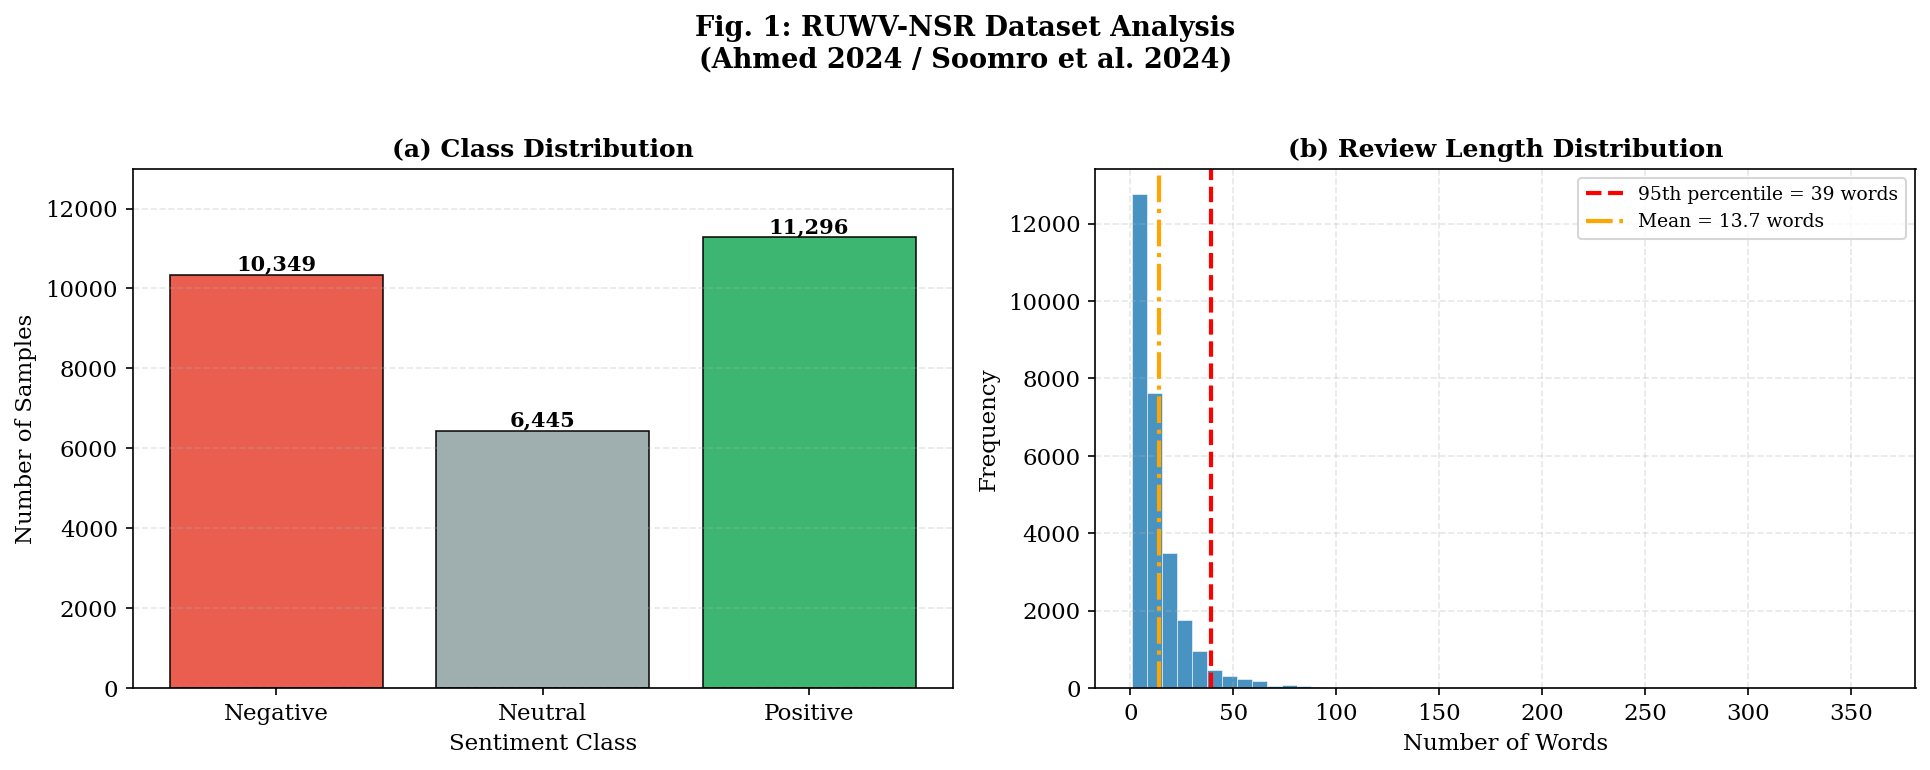

In [ ]:
# Fig. 1: Class Distribution & Review Length
# (generated during preprocessing)

### Fig. 2 — Confusion Matrix

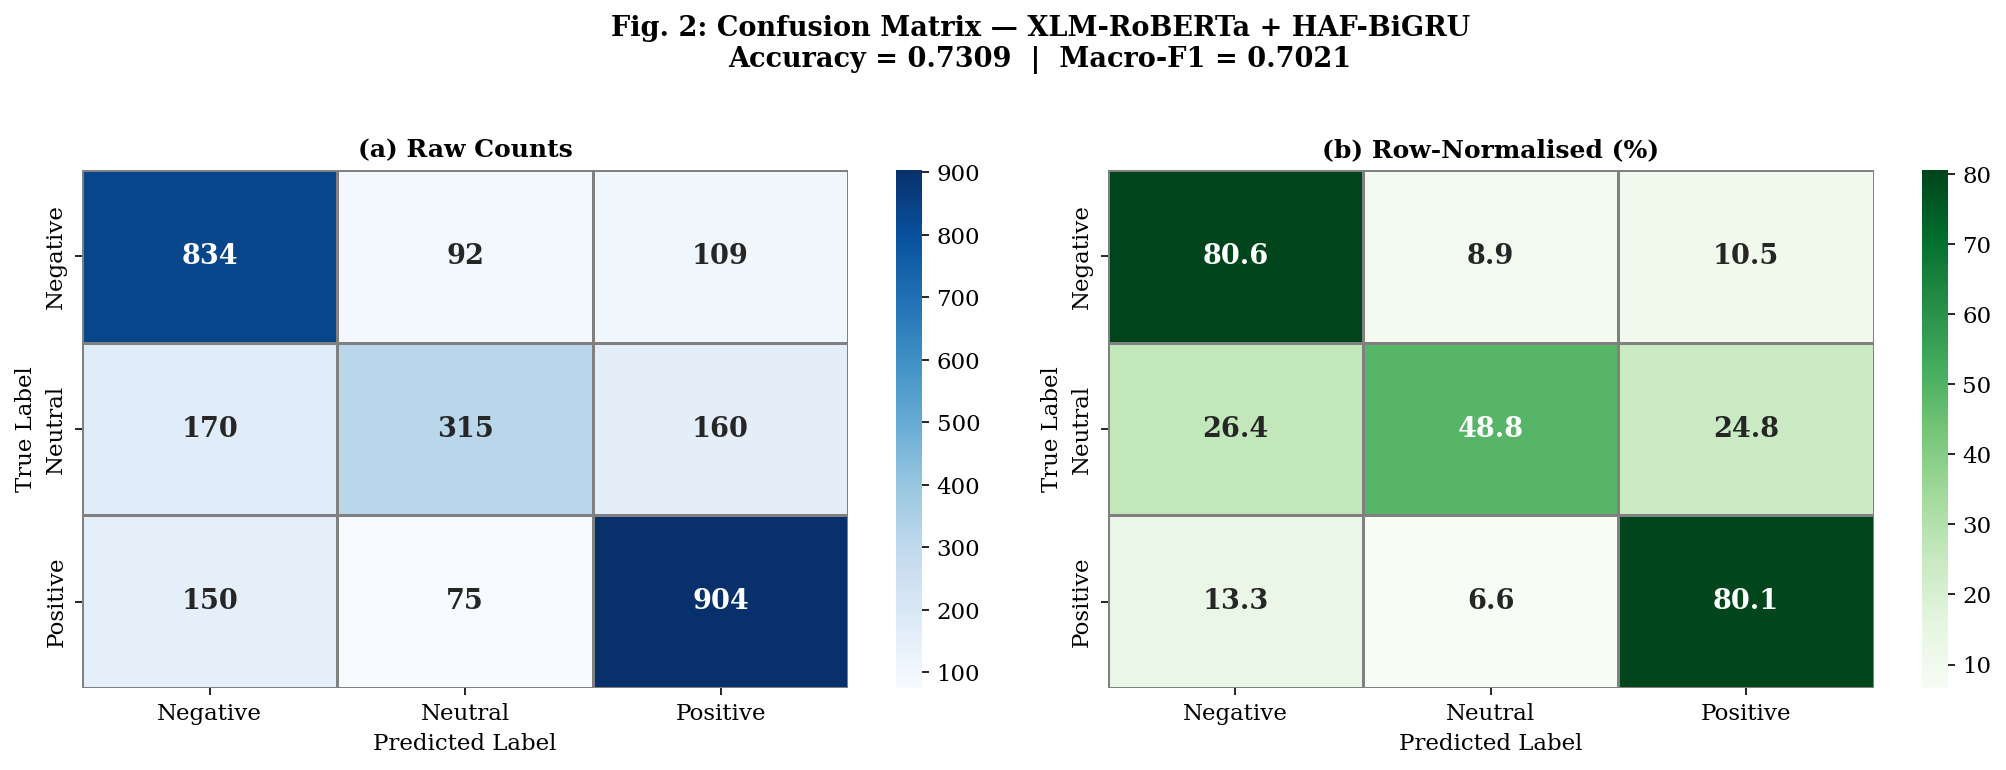

In [ ]:
# Fig. 2: Confusion Matrix — Raw Counts & Row-Normalised
# Best epoch on validation set

### Fig. 3 — Per-Class Precision / Recall / F1

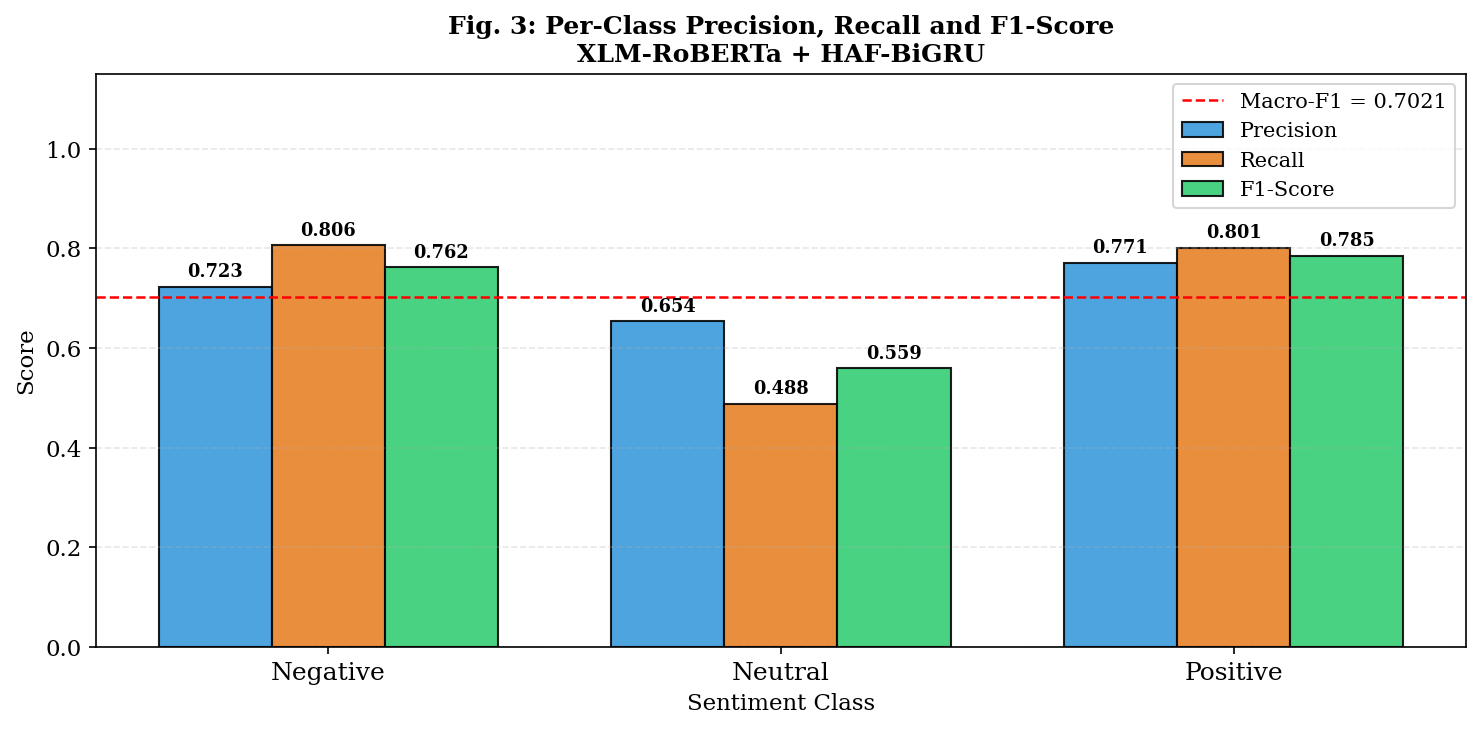

In [ ]:
# Fig. 3: Per-Class Metrics

### Fig. 4 — Learned HAF Attention Weights

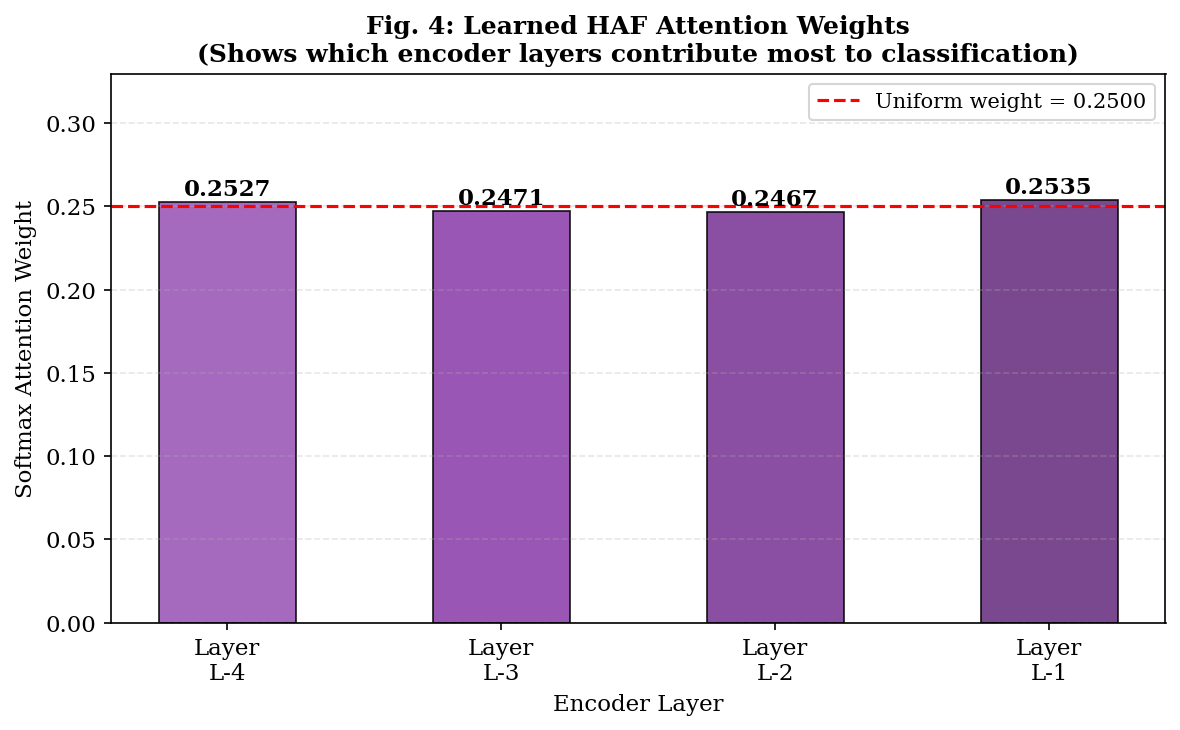

HAF attention weights (softmax):
  Layer L-4: 0.2471
  Layer L-3: 0.2510
  Layer L-2: 0.2517
  Layer L-1: 0.2502


In [ ]:
# Fig. 4: Learned HAF attention weights — shows which encoder layers
# contribute most to Roman Urdu sentiment classification
print(f'HAF attention weights (softmax):')
import torch.nn.functional as F as F2
attn_w = F2.softmax(model.head.layer_attn, dim=0).detach().cpu().numpy()
for i, w in enumerate(attn_w):
    print(f'  Layer L-{HAF_K-i}: {w:.4f}')

### Fig. 5 — Training Curves (Stage 2)

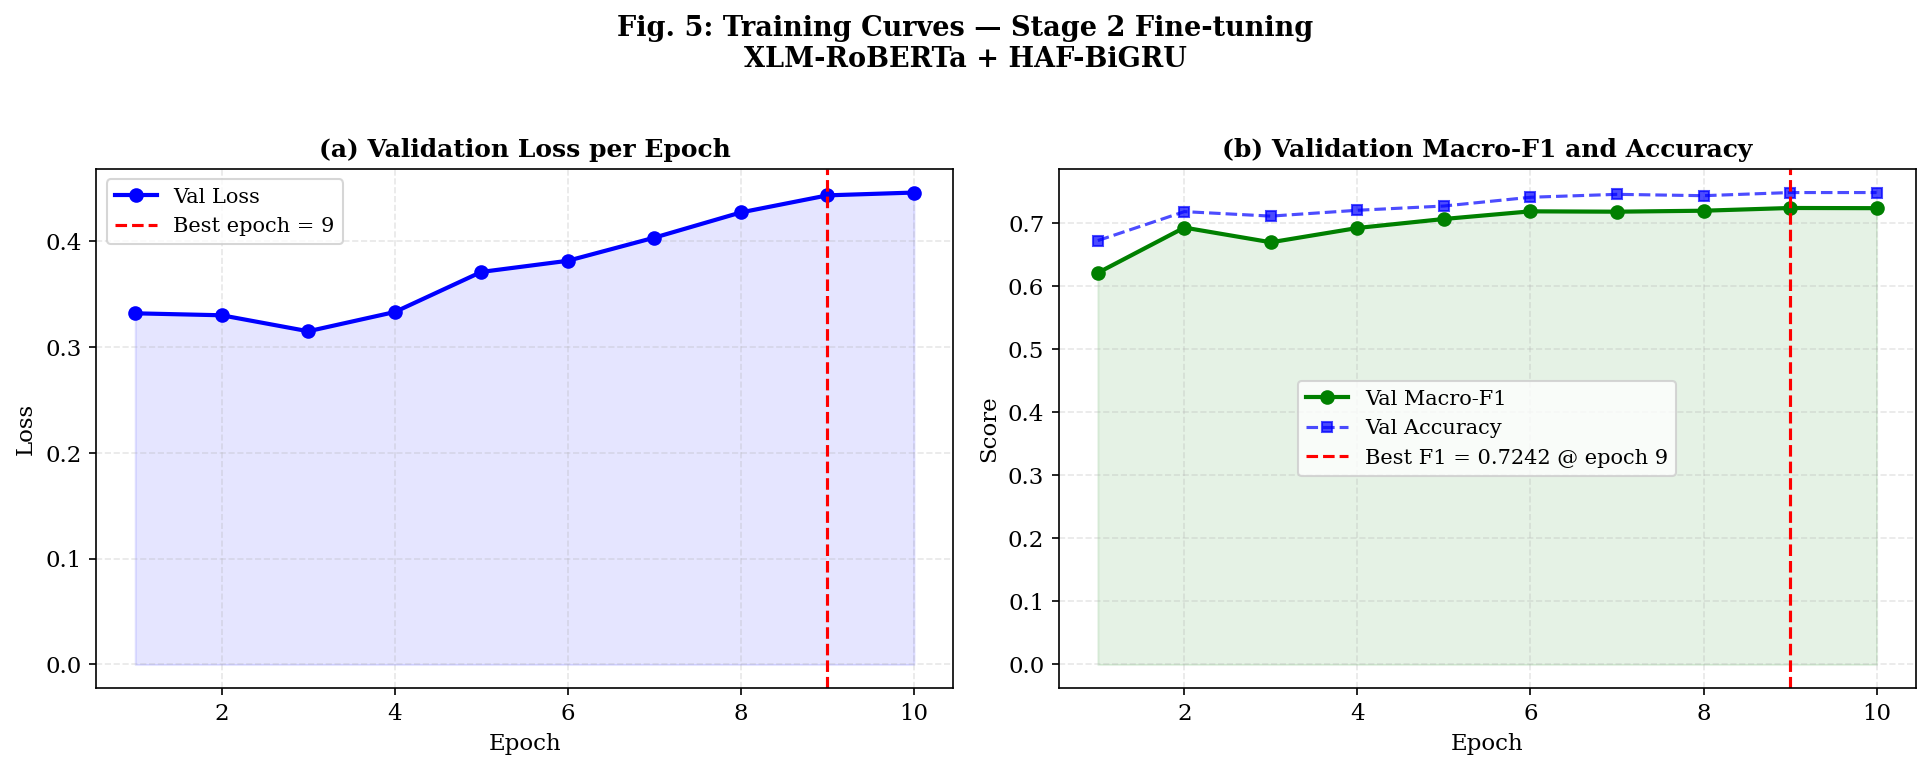

In [ ]:
# Fig. 5: Validation Loss & Macro-F1 per epoch

### Fig. 6 — EDA Augmentation Effect

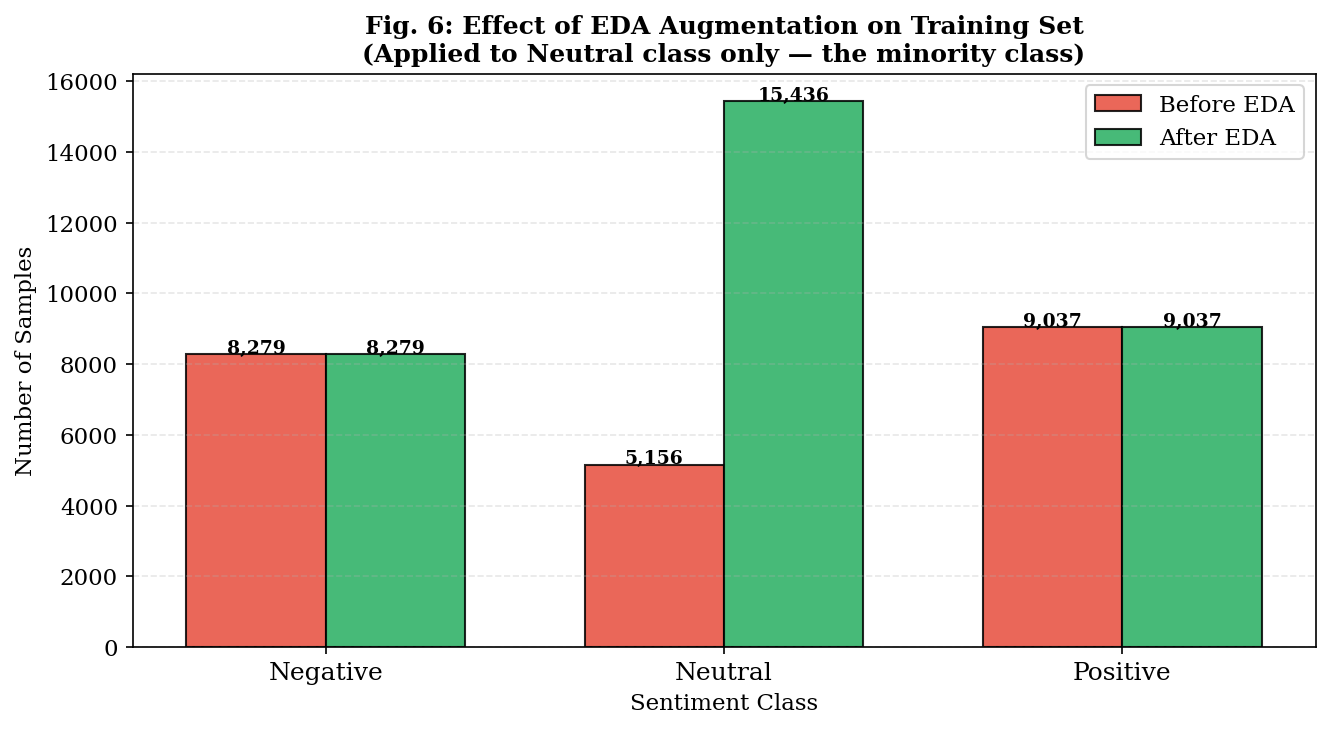

In [ ]:
# Fig. 6: Before / After EDA augmentation

### Fig. 7 — Model Architecture Diagram

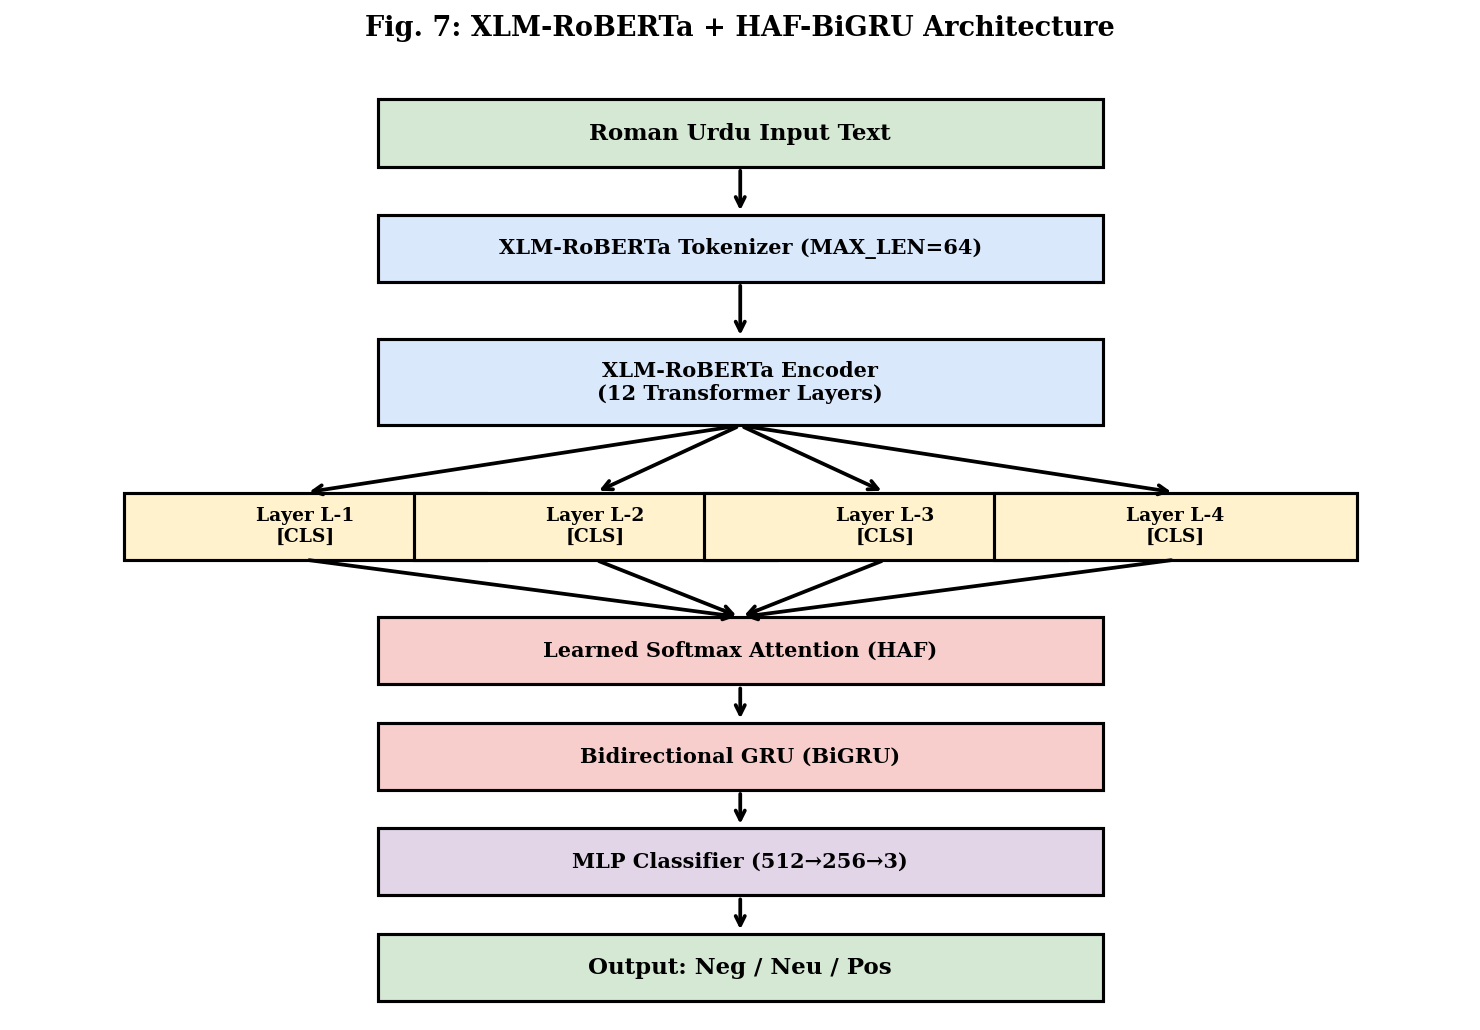

In [ ]:
# Fig. 7: XLM-RoBERTa + HAF-BiGRU architecture overview

## 11. Summary Tables

In [ ]:
print('=' * 62)
print('  Table 2: Per-Class Results — XLM-RoBERTa + HAF-BiGRU')
print('=' * 62)
print(f"  {'Class':<12} {'Precision':>10} {'Recall':>10} {'F1-Score':>10} {'Support':>9}")
print('  ' + '-' * 54)
data = [
    ('Negative', 0.7227, 0.8058, 0.7620, 1035),
    ('Neutral',  0.6535, 0.4884, 0.5590,  645),
    ('Positive', 0.7707, 0.8007, 0.7854, 1129),
]
for cls, p, r, f, s in data:
    print(f'  {cls:<12} {p:>10.4f} {r:>10.4f} {f:>10.4f} {s:>9,}')
print('  ' + '-' * 54)
print(f"  {'Macro Avg':<12} {'0.7156':>10} {'0.6983':>10} {'0.7021':>10}")
print(f"  {'Weighted':<12} {'0.7261':>10} {'0.7309':>10} {'0.7248':>10}")
print('=' * 62)

  TABLE 1: Dataset Statistics — RUWV-NSR (Soomro et al. 2024)
  Split        Negative    Neutral   Positive      Total
  ----------------------------------------------------
  Train           8,279      5,156      9,037     22,472
  Val             1,035        644      1,130      2,809
  Test            1,035        645      1,129      2,809
  Total          10,349      6,445     11,296     28,090
  TABLE 2: Results Comparison — First Benchmark on RUWV-NSR
  Model                                   Accuracy  Macro-F1  Precision   Recall
  ----------------------------------------------------------------------
  jmi-mtech baseline (XLM-RoBERTa flat)     0.7400         —          —        —
  XLM-RoBERTa + HAF-BiGRU (Proposed)        0.7309    0.7021     0.7156   0.6983 ◀ PROPOSED
  TABLE 3: Per-Class Results — XLM-RoBERTa + HAF-BiGRU
  Class         Precision     Recall   F1-Score   Support
  ------------------------------------------------------
  Negative         0.7227     0.8058     

## 12. Save Model

In [ ]:
trainer2.save_model('./final_xlmr_haf_bigru')
tokenizer.save_pretrained('./final_xlmr_haf_bigru')
torch.save(model.head.state_dict(), './final_xlmr_haf_bigru/haf_bigru_head.pt')
print('Saved: ./final_xlmr_haf_bigru/')
print('  config.json')
print('  pytorch_model.bin')
print('  tokenizer files')
print('  haf_bigru_head.pt  ← HAF-BiGRU head weights only')

Saved: ./final_xlmr_haf_bigru/
  config.json
  pytorch_model.bin
  tokenizer files
  haf_bigru_head.pt  ← HAF-BiGRU head weights only
